<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/PortfolioAnalysis/PortfolioAnalysis/Survivorship_and_Look_Ahead_Bias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas_ta

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import pandas_ta as ta # Optional library, but let's build RSI from scratch for transparency

# SURVIVORSHIP BIAS

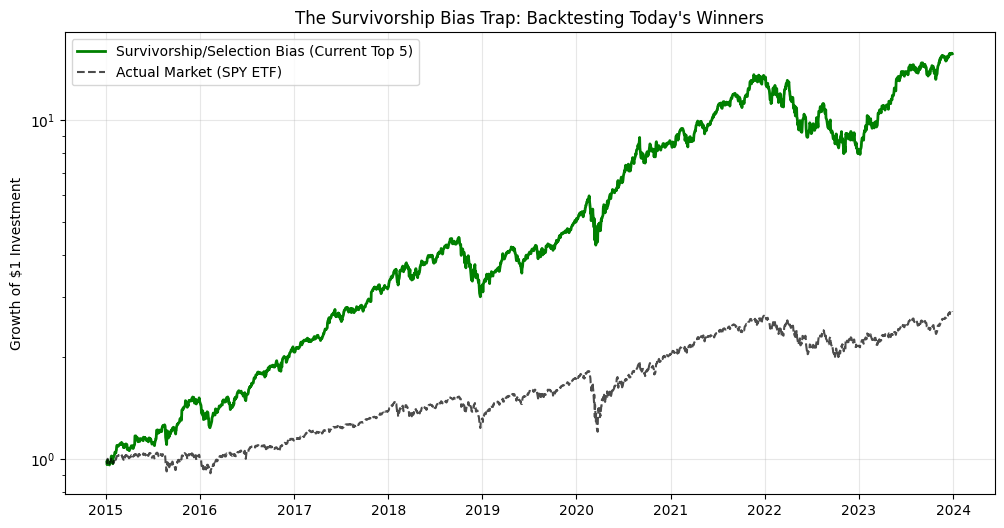

Biased Total Return: 15.69x
Actual Market Return: 2.72x


In [ ]:
# --- 1. DATA LOADING (Real Data) ---
# We download the "Current Winners" and the Market Benchmark
# Note: In 2015, NVDA was NOT a top 5 stock. Selecting it now for a 2015 backtest is Bias.
tickers = ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL']
benchmark_ticker = 'SPY' # S&P 500 ETF

start_date = '2015-01-01'
end_date = '2024-01-01'

print("Downloading data...")
# Download adjusted close prices (accounts for dividends/splits)
data = yf.download(tickers + [benchmark_ticker], start=start_date, end=end_date, progress=False, auto_adjust = False)['Adj Close']

# --- 2. THE BIASED "WINNERS" PORTFOLIO ---
# We assume we invested equally in these 5 giants back in 2015
stock_returns = data[tickers].pct_change().dropna()
# Equal weights (1/5 each)
biased_portfolio_returns = stock_returns.mean(axis=1)

# --- 3. THE REALITY (The Market Index) ---
# SPY includes the winners AND the losers (energy companies that crashed, retailers that failed, etc.)
benchmark_returns = data[benchmark_ticker].pct_change().dropna()

# --- 4. CUMULATIVE RETURNS ---
biased_equity = (1 + biased_portfolio_returns).cumprod()
benchmark_equity = (1 + benchmark_returns).cumprod()

# --- VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.plot(biased_equity, label='Survivorship/Selection Bias (Current Top 5)', color='green', linewidth=2)
plt.plot(benchmark_equity, label='Actual Market (SPY ETF)', color='black', alpha=0.7, linestyle='--')

plt.title("The Survivorship Bias Trap: Backtesting Today's Winners")
plt.ylabel("Growth of $1 Investment")
plt.yscale('log') # Log scale to show the magnitude of outperformance
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Biased Total Return: {biased_equity.iloc[-1]:.2f}x")
print(f"Actual Market Return: {benchmark_equity.iloc[-1]:.2f}x")

# LOOK-AHEAD BIAS

/tmp/ipython-input-3031574918.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start='2020-01-01', end='2024-01-01', progress=False)
/tmp/ipython-input-3031574918.py:23: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df['Position'] = df['Signal'].replace(to_replace=0, method='ffill')


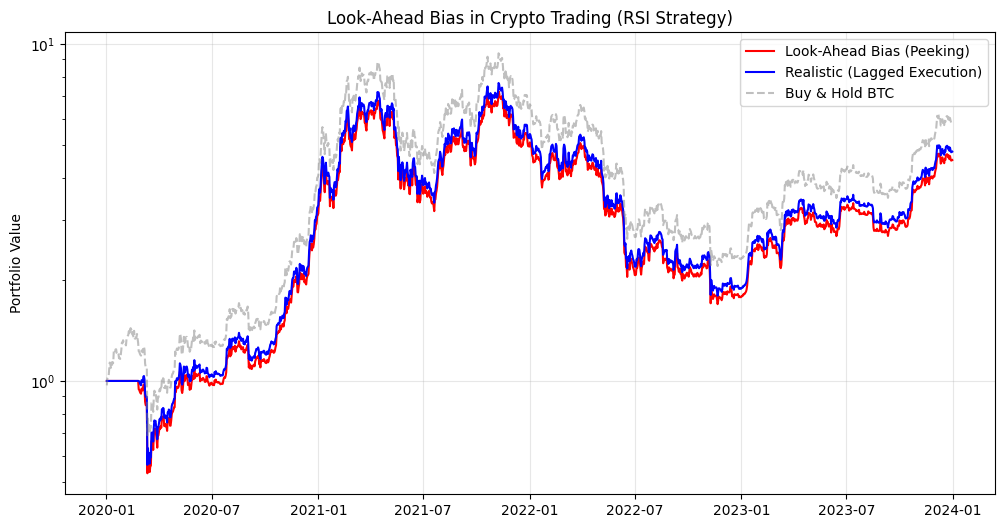

In [ ]:
# --- 1. DATA LOADING ---
# Fetch Bitcoin data
df = yf.download('BTC-USD', start='2020-01-01', end='2024-01-01', progress=False)

# Clean multi-index if necessary
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# --- 2. INDICATOR CALCULATION (RSI) ---
# Calculate RSI manually to ensure we know exactly what data goes in
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Strategy: Buy if RSI < 30 (Oversold), Sell if RSI > 70 (Overbought)
# Create a signal: 1 (Long), 0 (Cash)
df['Signal'] = 0
df.loc[df['RSI'] < 30, 'Signal'] = 1
df.loc[df['RSI'] > 70, 'Signal'] = 0
# Forward fill position (hold until signal changes)
df['Position'] = df['Signal'].replace(to_replace=0, method='ffill')
# (Note: simpler logic: 1=Hold, 0=Cash. We aren't shorting here for simplicity)

# --- 3. THE LOOK-AHEAD ERROR ---
# We multiply Position * Return of the SAME ROW.
# This assumes we knew the RSI (based on Close) before the day ended to capture that day's move.
df['Daily_Ret'] = df['Close'].pct_change()
df['Biased_Strategy'] = df['Position'] * df['Daily_Ret']

# --- 4. THE REALISTIC EXECUTION ---
# We must SHIFT the position. We calculate RSI at Close, so we enter at the NEXT Close (or Open).
# Shift(1) aligns "Yesterday's Signal" with "Today's Return"
df['Real_Strategy'] = df['Position'].shift(1) * df['Daily_Ret']

# --- 5. VISUALIZATION ---
# Calculate Cumulative Returns
df['Equity_Biased'] = (1 + df['Biased_Strategy']).cumprod()
df['Equity_Real'] = (1 + df['Real_Strategy']).cumprod()
df['Equity_BuyHold'] = (1 + df['Daily_Ret']).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Equity_Biased'], label='Look-Ahead Bias (Peeking)', color='red')
plt.plot(df.index, df['Equity_Real'], label='Realistic (Lagged Execution)', color='blue')
plt.plot(df.index, df['Equity_BuyHold'], label='Buy & Hold BTC', color='gray', linestyle='--', alpha=0.5)

plt.title("Look-Ahead Bias in Crypto Trading (RSI Strategy)")
plt.ylabel("Portfolio Value")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()